In [1]:
import matplotlib.pyplot as plt
import re

In [2]:
# Data pickup critical phase 1
DATA_P1 = r"""
18.9958* 22465.2 42898.5 29004.3 32316 
17.1592* 3.19554* 2270.11 3276.02 8853.59 9773.16 11211.7 10670.2 13849.8 15013 16454.9 17872.7 18880.6 20224.2 30028.2 
24.4306* 24.4507* 23.0428* 19.1571* 1673.95 
171545 157781 149718 114966 81548.3 69760.7 52674.8 39866.4 34284.1 23805.3 18167.2 6070.04 22.9954* 22.9141* 22.6306* 
179137 169281 159115 147135 98770.1 89728.8 79694.8 69270.1 47741.4 37058 33449.7 16860.2 12479.3 10314.2 5112.3 4918.86 2714.66 3077.64 23.3432* 
13.6178* 14161.4 15987.2 17505.5 26072.5 27188.7 29233.1 28413.7 31038.9 32033.7 32473 35002.1 36000.1 38383.8 38160.5 
130601 126290 120206 163992 102622 48527.9 46275.1 23300.3 23.5312* 
17.1592* 2990.57 4469.6 9411.12 10203.5 14486.7 18646.4 20378.8 19092.3 16244.5 18207.8 19376.3 20146.5 22286.3 22896.3 23692.8 23511.6 22600.1 30081.5 32859.2 35212.5 35873.7 36259.7 
176074 165910 133498 112148 92986.9 75160.6 65825.9 51925.3 28923.4 23081.3 9652.3 3164.15 3674.71 3344.94 4770.64 4209.67 5195.67 2118.26 23.3432* 
14.1365* 14.4927* 3202 16337.3 17878.6 19907.2 21113.7 21887.3 20684.2 21887.5 27477.3 31433.6 33975.6 33388.3 36377.1 37159.1 40368.6 39815 39290.3 
"""

DATA_P2 = r"""
9.35665* 9.05823* 1330.02 549.026 22.3046* 162.774 1195.62 3500.16 4548.24 6003.58 12683 14605.4 
11.4433* 11.1508* 19.769* 16.425* 7920.37 12002.8 16817.5 17656.8 17965.5 20388.3 21516.9 22563.4 23624.5 24773.9 26598 27910.4 
22.2099* 34.1122* 1696.8 7575.73 8454.14 9473.58 10535.8 
18.9002* 26.0077* 6202.34 8629.24 8785.06 11682.4 12471.8 13739 14597.6 15775.4 
14.3908* 2248.73 12530.4 14139.7 17409.9 20137.1 19017.4 19765.4 20538.9 21688.6 23071.1 24770.8 25954.6 
15.4422* 17.9901* 17.1112* 18.1309* 12.852* 1097.19 3240.43 4490.76 6333.13 8012.29 14051.8
16.5808* 814.546 623.904 19.6319* 5586.44 5651.53 6461.56 7722.51 9236.64 16506 18053.6 21345.6 23735.5 23104.9 26395.7 28650.5 26066.5 26385.3 27205.2 28803.4 30055.9 31833.7 32683.2 
15.6212* 457.525 962.698 25.7854* 4749.79 5455.73 6448.77 6623.72 7622.75 13887.6 16005.7 21556.1 25175.8 21946.3 24349.7 29244.4 27861.9 27125.8 26505.5 27376.8 28131.4 29624.9 30757 
3.50637* 3.48634* 3.6029* 3537.13 
15.4066* 17.1434* 16.1336* 14.4147* 7659.79 12121.4 22284.3 23617.3 24893.6 
"""

DATA_D1 = r"""
66310 56344.4 50378.9 31023 23663.2 16342.3 11228.9 7316.34 3950.79 4756.07 2484.17 23.8655* 25.2138* 2110.32 11906.8 14544.3 17256.3 18178.3 18492.7 
50183.7 39745.5 20706.3 18642.7 3.12631* 4.12448* 1398.04 
37618.9 32445.8 23927.9 15650.8 7307.23 2535.87 4.31522* 1.19174* 10.3097* 
287338 276840 272171 258212 221301 186635 171736 132581 117073 110569 100959 77668.2 66749.1 55100.1 20910.4 10318 2213.44 1192.74 12.0314* 
229775 215729 208807 195676 164500 136045 125350 96675 85400.4 77293.6 69148.3 50123.5 40238.5 27421.2 6762.85 3533.71 0.31181* 
40380.5 38264.2 36095.3 27973.5 10.942* 3151.77 4564.67 
235329 221870 205465 202271 170011 141725 125123 97488 86068.2 77531.6 68783.9 49032.9 37985.5 25815.4 6279.31 3390.22 18.583* 17.4817* 7.04248* 
4.23451* 3.78652* 2699.06 6459.08 16397.7 17530.9 18560.6 19675.4 20842.2 
54861.7 44544.6 33605.4 24068.8 17157 12025.5 5368.23 4218.69 1933.25 1894.9 494.019 2111.94 3676.31 7708.42 9138.28 11870.6 21936.9 
15850 5278.07 2716.36 36.8276 23.1517* 1235.37 1420.61 1841.82 2331.29 4788.48 3468.88 6354.19 14033.8 15365.8 16867.5 18197.2 19592.4 20970.3 20736.1 
"""

DATA_D2 = r"""
19480 18371.9 29.0623* 34.1093* 32.0735* 11.5838* 
14198.6 11179.2 10070.6 8809.27 7312.72 6312.39 4794.33 5.15806* 5.65887* 2.42563* 2.6717* 
22169.8 20845.1 20093.9 18136.4 16747.5 15598.5 13629.3 12310.2 11913.2 4490.54 5950.12 37.1528* 21.7962* 
11731.6 9743.47 8681.34 7781.96 6948.93 5974.67 5298.38 2143.72 2.71144* 1.20091* 0.72182* 
15421.1 14330.7 12791.7 6122.03 4974.33 3612.46 37.1341* 19.1399* 19.1487* 
27089.9 26093.1 24130.1 20323.5 18997.4 17620.3 15849.4 15109.9 12752.1 10607.2 7333.41 5731.19 1019.98 208.664 24.7672* 23.3091* 9.20865* 
25229 24157.6 16973.6 15581.4 14327 11875.3 10867.7 3564.68 6.86935* 
17220.3 12010.1 10965.6 9861.08 7780.38 2471.1 1.25033* 
5704.91 4549.64 3171.78 593.492 24.0752* 18.4573* 21.4852* 18.5617* 19.2899* 19.1494* 
14985.2 12782.6 8025.45 7839.4 5837.37 4728.03 3601.64 28.2355* 23.6866* 19.3712* 
"""

In [3]:
def plot_data(data, title):
    plt.figure(figsize=(10, 6))
    plt.title(title)

    for i, line in enumerate(data.strip().splitlines()):
        values = []
        starred_x = []
        starred_y = []

        for j, token in enumerate(line.split()):
            starred = token.endswith("*")
            value = float(token.rstrip("*"))

            values.append(value)

            if starred:
                starred_x.append(j)
                starred_y.append(value)

        x = range(len(values))

        # Lines with 'o' markers for all points
        line_obj, = plt.plot(
            x, values,
            marker='o',
            markersize=4,
            linewidth=1.5,
            alpha=0.8
        )

        # Feasible with '*' a cross marker
        plt.scatter(
            starred_x,
            starred_y,
            marker='x',
            s=80,
            linewidths=2,
            color=line_obj.get_color(),
            zorder=5
        )

    plt.xlabel("Insertion position")
    plt.ylabel("Cost of insertion")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

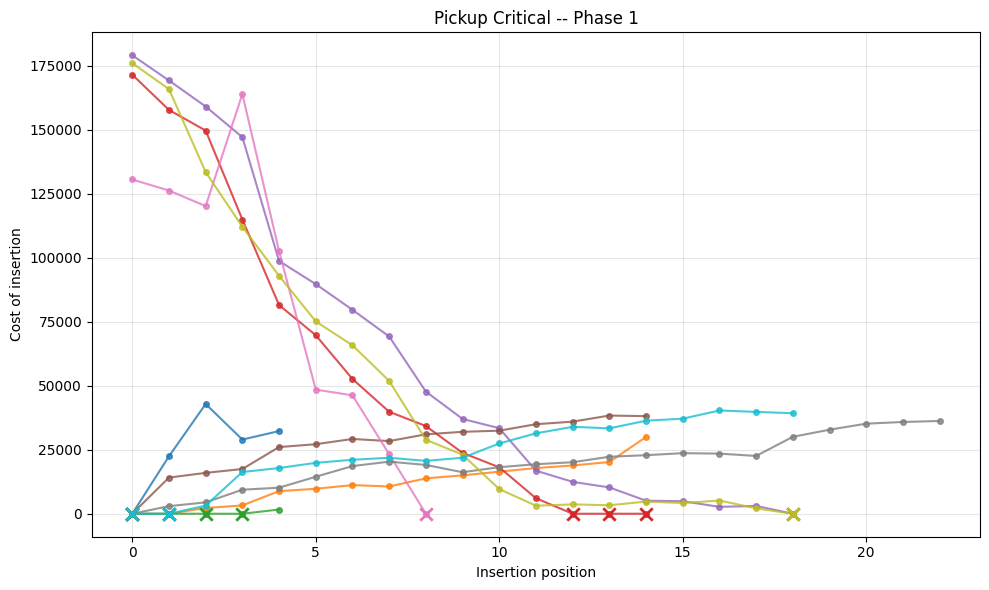

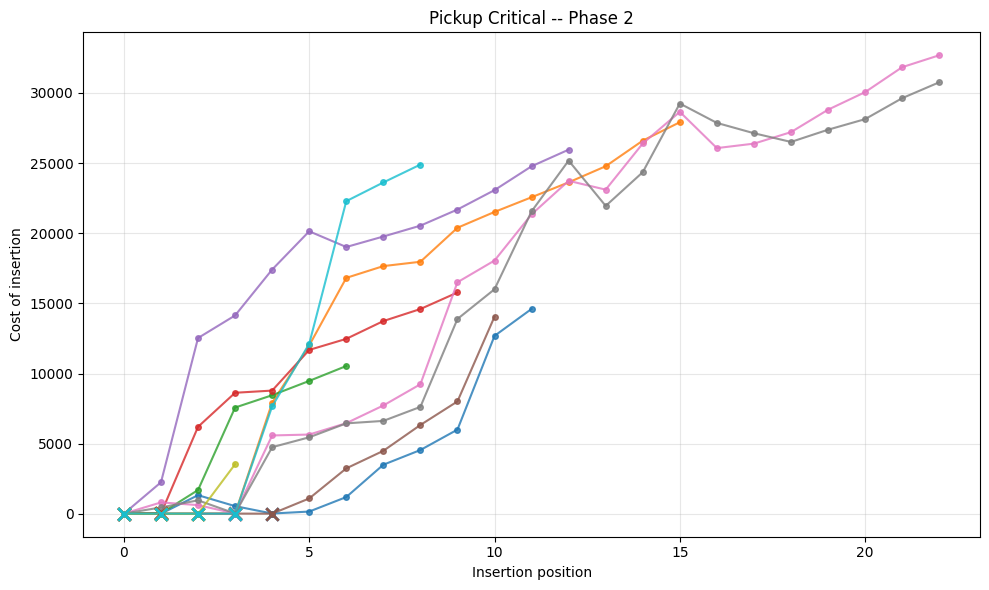

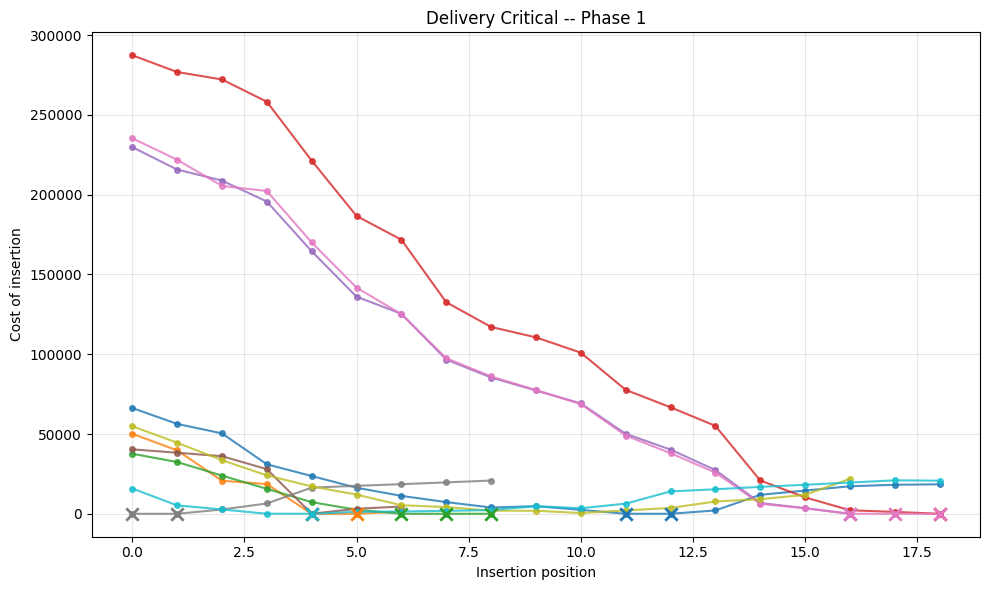

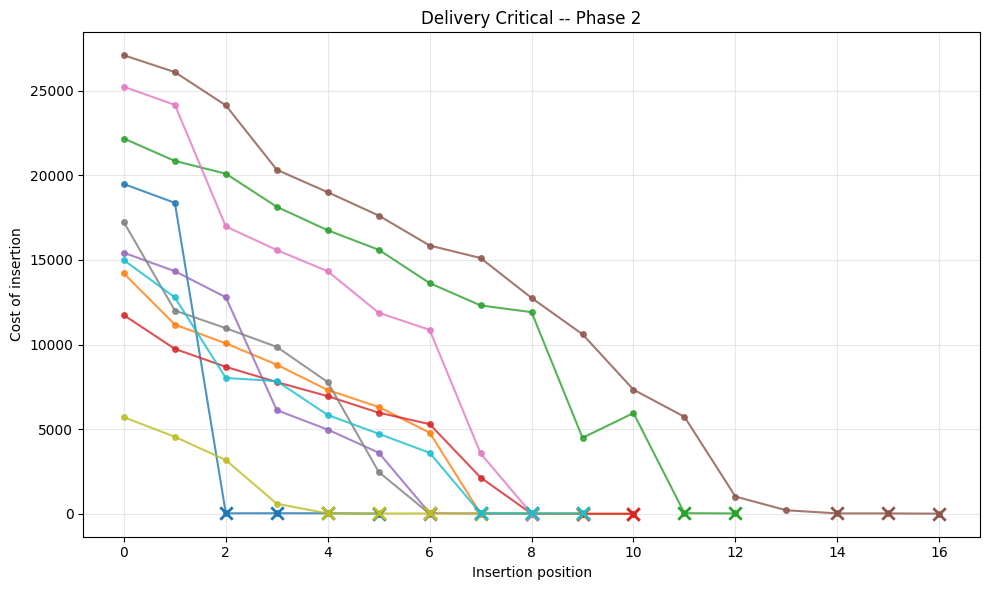

In [4]:
plot_data(DATA_P1, "Pickup Critical -- Phase 1")
plot_data(DATA_P2, "Pickup Critical -- Phase 2")
plot_data(DATA_D1, "Delivery Critical -- Phase 1")
plot_data(DATA_D2, "Delivery Critical -- Phase 2")